# 01 — Extract Top Circuits

Parse the Pareto front from a GCAD mining run and select the best representative from each structurally distinct architecture.

**Output:** `selected_M_circuits.pkl`

In [1]:
import os
# Navigate to repo root so all relative paths resolve correctly.
if os.path.basename(os.getcwd()) in ('notebooks', 'examples'):
    os.chdir('..')

In [2]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from gcad.circuit import Topo  # required for safe pickle deserialization

INPUT_DIR = os.path.join("data", "gcad_results")  # folder containing final_objectives_df.pkl and final_population.pkl
M_TARGET = 3               # number of distinct architectures to extract

## Load and Annotate Pareto Front

In [3]:
def abstract_edges(edge_list):
    """Map specific part names to generic roles for architecture-level deduplication."""
    generic = []
    for u, v in edge_list:
        src = 'P1' if u == 'P1' else ('A' if u.startswith('Z') else ('R' if u.startswith('I') else u))
        tgt = 'Rep' if v == 'Rep' else ('A' if v.startswith('Z') else ('R' if v.startswith('I') else v))
        generic.append((src, tgt))
    return tuple(sorted(generic))

df = pd.read_pickle(os.path.join(INPUT_DIR, "final_objectives_df.pkl"))
with open(os.path.join(INPUT_DIR, "final_population.pkl"), "rb") as f:
    pop = pickle.load(f)

df['circuit_object'] = [ind[0] for ind in pop]
if 'prominence_rel' in df.columns and df['prominence_rel'].mean() < 0:
    df['prominence_rel'] = -df['prominence_rel']

df['topology_sig'] = df['circuit_object'].apply(lambda c: str(tuple(sorted(c.edge_list))))
df['abstract_sig'] = df['circuit_object'].apply(lambda c: abstract_edges(c.edge_list))

valid_df = df[df['prominence_rel'] > 0.1].copy()
print(f"Loaded {len(pop)} circuits. {len(valid_df)} pass prominence > 0.1.")

Loaded 200 circuits. 200 pass prominence > 0.1.


## Select Best Circuit Per Architecture

In [4]:
abs_counts = valid_df['abstract_sig'].value_counts().reset_index()
abs_counts.columns = ['abstract_sig', 'Count']
top_archs = abs_counts.head(M_TARGET)

selected_circuits = []
for i, row in top_archs.iterrows():
    subset = valid_df[valid_df['abstract_sig'] == row['abstract_sig']]
    best_row = subset.sort_values('prominence_rel', ascending=False).iloc[0]
    selected_circuits.append(best_row['circuit_object'])
    print(f"Circuit {i+1}: arch={row['abstract_sig']} | prominence={best_row['prominence_rel']:.2f}")

print(f"\nExtracted {len(selected_circuits)} structurally distinct circuits.")

Circuit 1: arch=(('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('R', 'A')) | prominence=28.49
Circuit 2: arch=(('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('R', 'A'), ('R', 'Rep')) | prominence=7.71
Circuit 3: arch=(('A', 'A'), ('A', 'R'), ('A', 'Rep'), ('P1', 'A'), ('P1', 'R'), ('R', 'A')) | prominence=29.53

Extracted 3 structurally distinct circuits.


## Visualize Selected Circuits

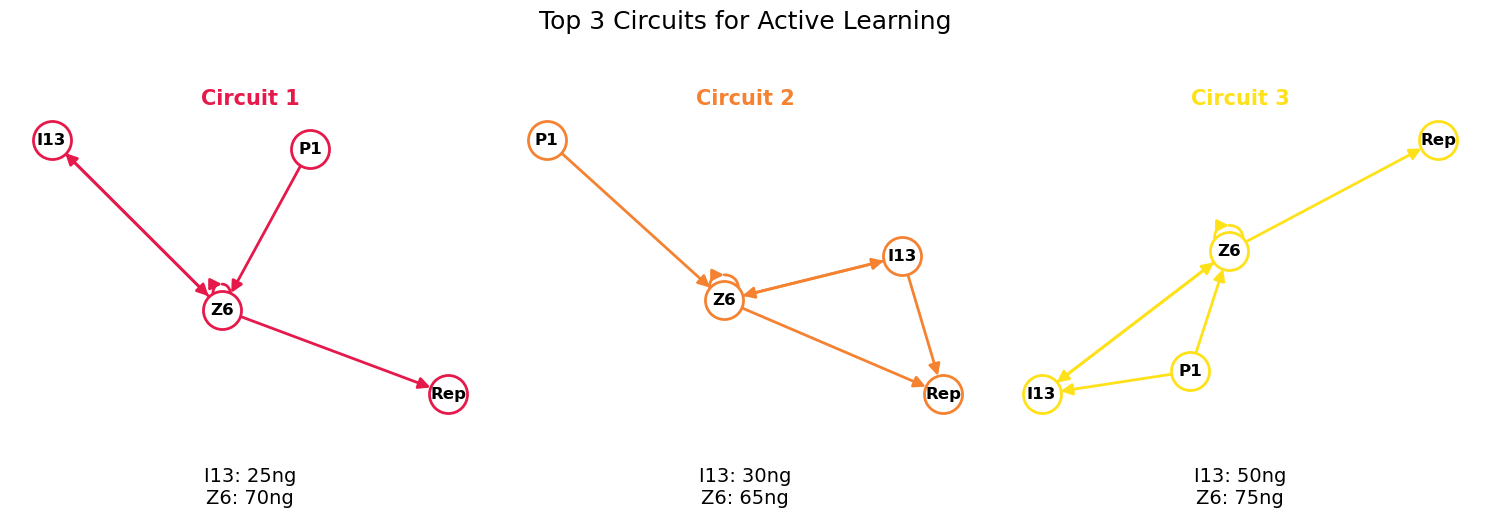

In [5]:
COLORS = ['#e6194B', '#f58231', '#ffe119']
fig, axes = plt.subplots(1, len(selected_circuits), figsize=(5 * len(selected_circuits), 5))
if len(selected_circuits) == 1:
    axes = [axes]

for i, circuit in enumerate(selected_circuits):
    ax = axes[i]
    color = COLORS[i % len(COLORS)]
    G = nx.DiGraph(circuit.edge_list)
    pos = nx.spring_layout(G, seed=25)
    nx.draw(G, pos, ax=ax, node_color='white', edgecolors=color, linewidths=2, node_size=750,
            with_labels=True, font_weight='bold', font_size=12, edge_color=color, width=2, arrowsize=17)
    ax.set_title(f"Circuit {i+1}", color=color, fontweight='bold', fontsize=15)
    dose_str = "\n".join([f"{k}: {v}ng" for k, v in circuit.dose.items() if k != 'Rep'])
    ax.text(0.5, -0.15, dose_str, transform=ax.transAxes, ha='center', va='top', fontsize=14)

plt.suptitle(f"Top {M_TARGET} Circuits for Active Learning", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## Save

In [6]:
with open(os.path.join("data", "selected_M_circuits.pkl"), 'wb') as f:
    pickle.dump(selected_circuits, f)
print("Saved selected circuits to 'selected_M_circuits.pkl'.")

Saved selected circuits to 'selected_M_circuits.pkl'.
